In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
X = dataset.iloc[:, [3,4]].values

C:\Anaconda3\envs\aiml\lib\site-packages\sklearn\cluster\_optics.py:903: RuntimeWarning: divide by zero encountered in true_divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


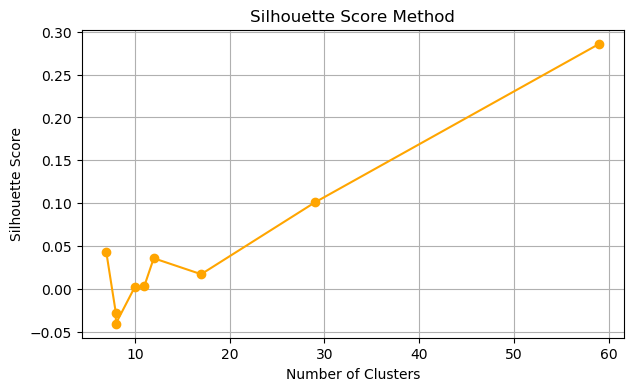

In [4]:
#Trying to change the eps & min_sample for 1 to 11
#storing the n_clusters & silhoutte score in 2 different lists
#plotting n_clusters & silhoutte score
#choose the number of cluster with the highest score. (i.e) n_cluster is 5. IT DOESN'T WORK FOR THIS ALGORITHM

from sklearn.cluster import OPTICS
from sklearn.metrics import silhouette_score
sil_scores = []
num_clusters =[]
for i in range(2,11):
    clustering = OPTICS(min_samples=i)
    clustering.fit(X)
    n_clusters = len(set(clustering.labels_))
    num_clusters.append(n_clusters)
    sil_score = silhouette_score(X, clustering.labels_)
    sil_scores.append(sil_score)
    
plt.figure(figsize=(7, 4))
plt.plot(num_clusters, sil_scores, marker='o', color='orange')
plt.title('Silhouette Score Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()

In [5]:
from sklearn.cluster import OPTICS
clustering = OPTICS(min_samples=8)
y = clustering.fit_predict(X)
y


array([-1,  3,  0,  3, -1,  3,  0, -1,  0,  3,  0, -1,  0,  3,  0,  3, -1,
        3, -1, -1, -1,  3,  0,  3,  0,  3, -1, -1, -1,  3,  0,  3,  0, -1,
        0,  3,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1,  1, -1,  2,  1,  2,  2,  1,  1,  1,  2,  1,  2,  1,
       -1, -1, -1,  2,  1,  1,  2,  1,  1, -1,  2,  1,  1,  1,  2, -1, -1,
       -1, -1, -1, -1,  6, -1,  5, -1,  6,  4,  5,  4,  5, -1,  5,  4,  6,
        4,  5,  4,  5,  4,  6, -1,  6,  4,  6, -1,  5, -1,  6,  4,  6,  4,
        5,  4,  6,  4,  5,  4,  5, -1,  5,  4,  6, -1,  5, -1,  6, -1, -1,
       -1, -1,  4,  6, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [6]:
supervised = dataset
supervised["Cluster_group"] = y
supervised.to_csv("OPTICS_Clusters.csv")

C:\Anaconda3\envs\aiml\lib\site-packages\seaborn\regression.py:582: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


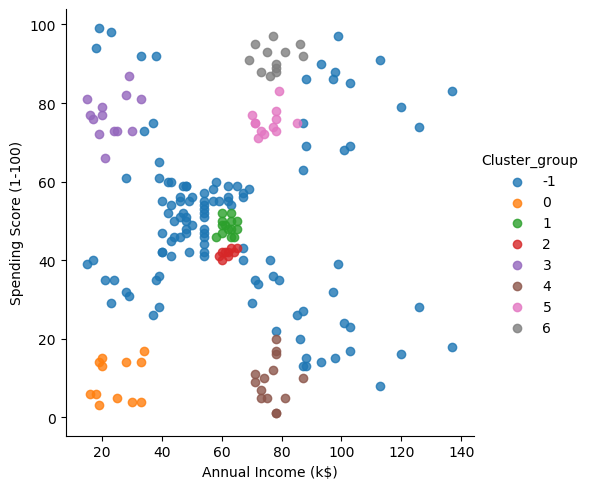

In [7]:
import seaborn as sns
facet = sns.lmplot(data = supervised, x=supervised.columns[3], y= supervised.columns[4], hue = supervised.columns[5], fit_reg = False, legend=True, legend_out=True)